# Battery Lifetime Prediction — RFM Model (With PSD Features)

This notebook trains a Random Forest Model (RFM) to predict battery lifetime (number of cycles before SOH drops to 90%), adding PSD (Power Spectral Density) frequency-domain features from the charging current (CC) and voltage (CV) waveforms to the four basic cyclic features.

Adding PSD features improves performance over the baseline RFM: MdAPE drops from 8.86% to 8.03% and R² improves from 0.598 to 0.705. The RFM with PSD features is the best-performing model overall and is used for the SHAP analysis in `rfm_shap_2000.ipynb`.

A grid search over max_depth and max_features finds the best parameters to be max_depth = 250, max_features = 0.6.

Note: trained models are not saved in this repo.

**Pipeline overview:**
1. Load preprocessed cyclic data from disk
2. Assemble cyclic feature matrix from first 100 cycles
3. Load and append PSD features (CC and CV)
4. Build target variable (cycles to SOH threshold)
5. Grid search over RFM hyperparameters
6. Train best model and evaluate on holdout
7. Save feature importances

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import keras
import numpy as np
import os
import seaborn as sns


from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.model_selection import  train_test_split
from sklearn.model_selection import GridSearchCV

import pickle

import gzip


os.chdir('../')
from functions.model_wrapper import Tree_Model, rfm_params, get_y_w_threshold


# These are batteries that show anomalies in the measnurements, and are therefore excluded.
excl_filenames = ['2018-04-12_batch8_CH46', '2017-06-30_3_6C-30per_6C_CH15', '2017-06-30_2C-7per_5_5C_CH12',
                  '2018-04-12_batch8_CH46', '2017-06-30_6C-60per_3C_CH48']

## 1. Load preprocessed cyclic data

Loads the filtered per-cycle feature DataFrames from disk, produced by `battery_dataprep.ipynb`.

In [2]:
with gzip.open('data/filtered_data_frames.pckl', 'rb') as f:
    data_frames = pickle.load(f)

## 2. Assemble cyclic feature matrix

Only the first 100 cycles are used. The cyclic feature DataFrames are concatenated and transposed so each row is one battery and each column is one feature-cycle combination.

In [3]:
first100rows_data_frames = [data_frame.iloc[: 100, :] for data_frame in data_frames]
X_all = pd.concat(first100rows_data_frames, axis = 0)
X_all = X_all[[col for col in X_all.columns if col not in excl_filenames]]
X_all = X_all.T

## 3. Load and append PSD features

PSD peak areas for the charging current (CC) and voltage (CV) are loaded from disk and appended to the cyclic feature matrix. NaN values are filled with 0. The schedule_version column (charging protocol version) is encoded as a boolean flag.

In [4]:
with gzip.open('data/CV_data_frames_FFT.pckl', 'rb') as f:
    CV_data_frames_FFT = pickle.load(f)
df_FF_peaks = pd.concat(CV_data_frames_FFT)

X_all = pd.merge(X_all, df_FF_peaks, left_index=True, right_index=True)

In [5]:
X_all.fillna(0, inplace = True)

# Convert schedule_version to categoric variable.

In [6]:
X_all["schedule_version"] = X_all["schedule_version"] == '7.00.08'

In [7]:
X_CC = data_frames[0]
X_CC = X_CC[[col for col in X_CC.columns if col not in excl_filenames]]

# get y which is number of cycle it dropped below threshold
threshold = 0.9
y_all = get_y_w_threshold(X_CC, threshold)

## 4. Build target variable

The target variable is the number of cycles before each battery's charge capacity drops below 90% of its initial value (SOH threshold = 0.9).

# Create Grid Search parameters

## 5. Grid search over RFM hyperparameters

Grid search over max_depth [250, 500, 1000] and max_features [0.7, 0.6, 0.5, 'sqrt', 'log2']. Both RMSE and R² metrics are used. Best parameters: max_depth = 250, max_features = 0.6.

### 5a. Grid search using RMSE

In [9]:
parameters = {'max_depth' : [250, 500, 1000],
              'max_features' : [0.7, 0.6, 0.5, 'sqrt', 'log2'],
             }
# I reduced the number of estimators and n_jobs for grid search
rfm_params = {'n_estimators': 80,
 # 'max_features': 0.5,
 # 'max_depth': 300,
 'bootstrap': True,
 'criterion': 'squared_error',
 'verbose': 1,
 'oob_score': True,
 'n_jobs': 8}

rfm_params["n_estimators"] = 40
rfm_params["n_jobs"] = 2
rfm_params["verbose"] = 0

# Grid search w RMS error as metric

### 5b. Grid search using R²

/Users/willtong/Library/Caches/pypoetry/virtualenvs/wine-libraries-e_IOXrlx-py3.12/lib/python3.12/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


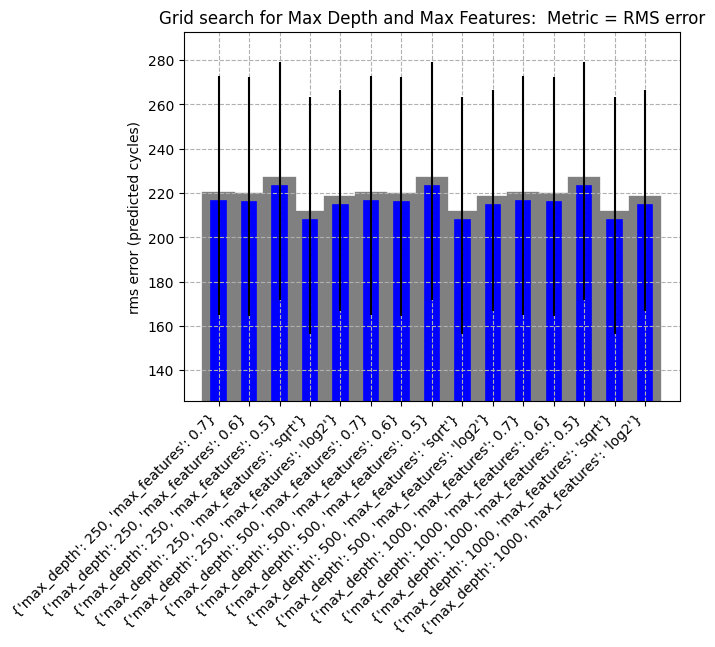

In [10]:
rfm = RandomForestRegressor(random_state = 1)
rfm.set_params(**rfm_params)
clf_rmse = GridSearchCV(rfm, parameters, scoring = 'neg_root_mean_squared_error', cv = 6)
clf_rmse.fit(X_all, y_all.values)

plt.title("Grid search for Max Depth and Max Features:  Metric = RMS error")
xlabels = [x for x in map(str, clf_rmse.cv_results_["params"])]
plt.bar(xlabels, 
        height = -clf_rmse.cv_results_["mean_test_score"],
        yerr=clf_rmse.cv_results_["std_test_score"],
        color = ['blue'],
        edgecolor = ['grey'],
        linewidth = 6
       )
plt.ylabel("rms error (predicted cycles)")
plt.xticks(rotation = 45, horizontalalignment="right")
plt.ylim(-clf_rmse.cv_results_["mean_test_score"].max()*0.6, -clf_rmse.cv_results_["mean_test_score"].min()*1.3)
plt.grid(linestyle = "--")
plt.show()

## 6. Train best model

**Result: Holdout MdAPE = 8.03%, R² = 0.705** — best performance of all models tested.

# Grid search w R^2 as metric

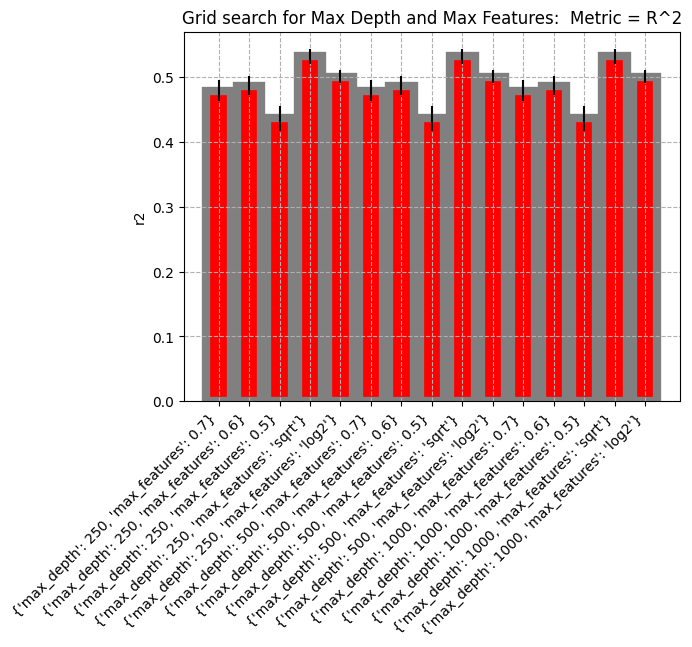

In [11]:
# Use R^2 as a metric for grid search
clf_r2 = GridSearchCV(rfm, parameters, scoring = 'r2', cv = 6)
clf_r2.fit(X_all, y_all.values)
plt.title("Grid search for Max Depth and Max Features:  Metric = R^2")
plt.bar(xlabels, 
        clf_r2.cv_results_["mean_test_score"], 
        yerr=clf_r2.cv_results_["std_test_score"]/10,
        color = ['r'],
        edgecolor = ['grey'],
        linewidth = 6
       )
plt.ylabel(clf_r2.scoring)
plt.xticks(rotation = 45, horizontalalignment="right")
# plt.ylim(clf_r2.cv_results_["mean_test_score"].min()*0.95, clf_r2.cv_results_["mean_test_score"].max()*1.05)
plt.grid(linestyle = "--")
plt.show()

# Best parameters: are max_depth = 250, max_features = 0.6

## 7. Save data and feature importances

Save the feature matrix, target variable, and trained model to disk for use in the SHAP analysis notebook (`rfm_shap_2000.ipynb`).

In [8]:
rfm_params["n_estimators"] = 100000
rfm_params["n_jobs"] = 6
rfm_params["max_depth"] = 250
rfm_params["max_features"] = 'sqrt'
rfm_params["verbose"] = 1


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, 
                                                    train_size=0.8, test_size=0.2, 
                                                    random_state=120)

[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:    0.4s
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:    0.6s
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:    0.8s
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:    1.0s
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:    1.3s
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed:    1.6s
[Parallel(n_jobs=6)]: Done 6038 tasks      | elapsed:    1.9s
[Parallel(n_jobs=6)]: Done 7188 tasks      | elapsed:    2.3s
[Parallel(n_jobs=6)]: Done 8438 tasks      | elapsed:    2.7s
[Parallel(n_jobs=6)]: Done 9788 tasks      | elapsed:    3.1s
[Parallel(n_jobs=6)]: Done 11238 tasks      | elapsed:  

Finished fitting.  Predicting X...


[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 6038 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 7188 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 8438 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 9788 tasks      | elapsed:    0.4s
[Parallel(n_jobs=6)]: Done 11238 tasks      | elapsed:  

Finished predicting X.
Training MdAPE is 4.934670526315789% (not holdout).
Finished training mdoel
MdAPE is 4.934670526315789%
R2: 0.939, RMSE: 79.695, MAE: 49.517
Plotting scatter plot...


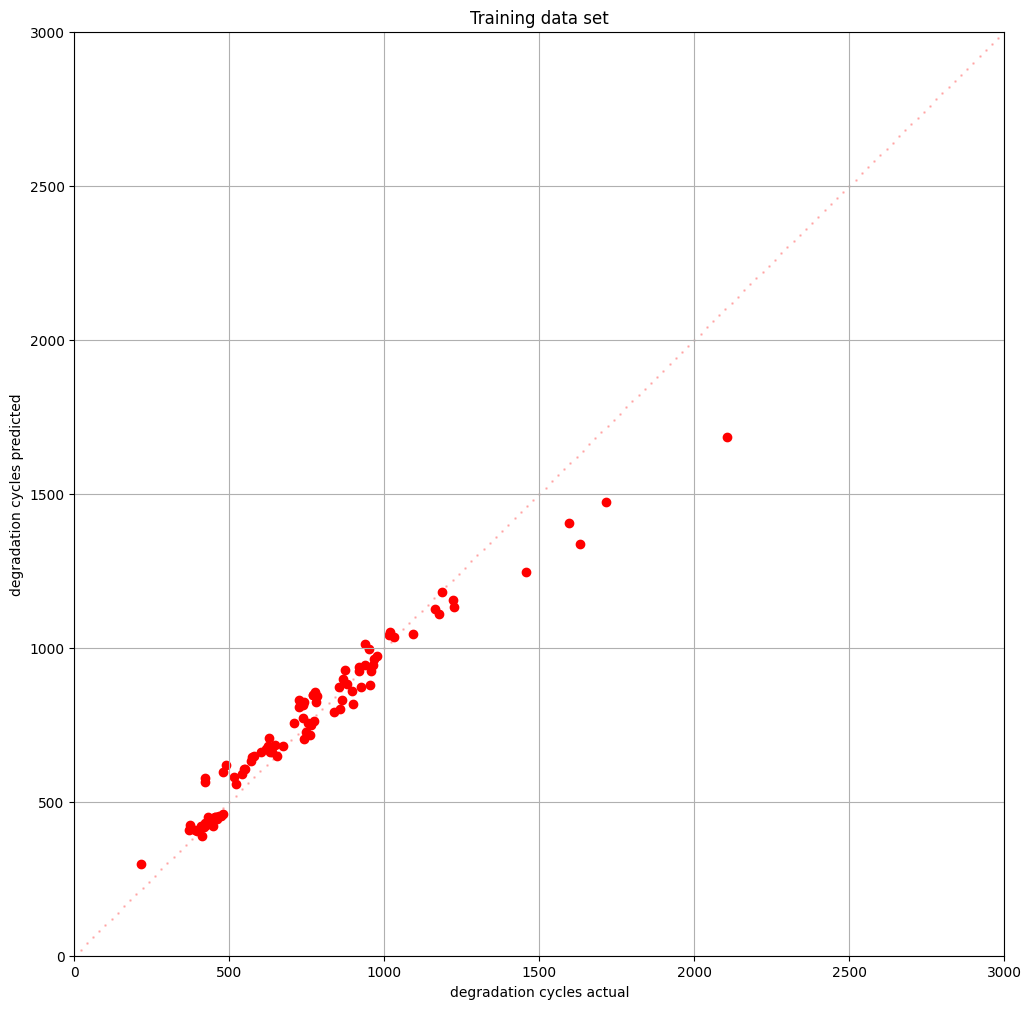

[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:    0.1s
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 6038 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 7188 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 8438 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 9788 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 11238 tasks      | elapsed:  

MdAPE is 8.37052727272728%
R2: 0.629, RMSE: 197.448, MAE: 127.379
Plotting scatter plot...


[Parallel(n_jobs=6)]: Done 100000 out of 100000 | elapsed:    2.9s finished


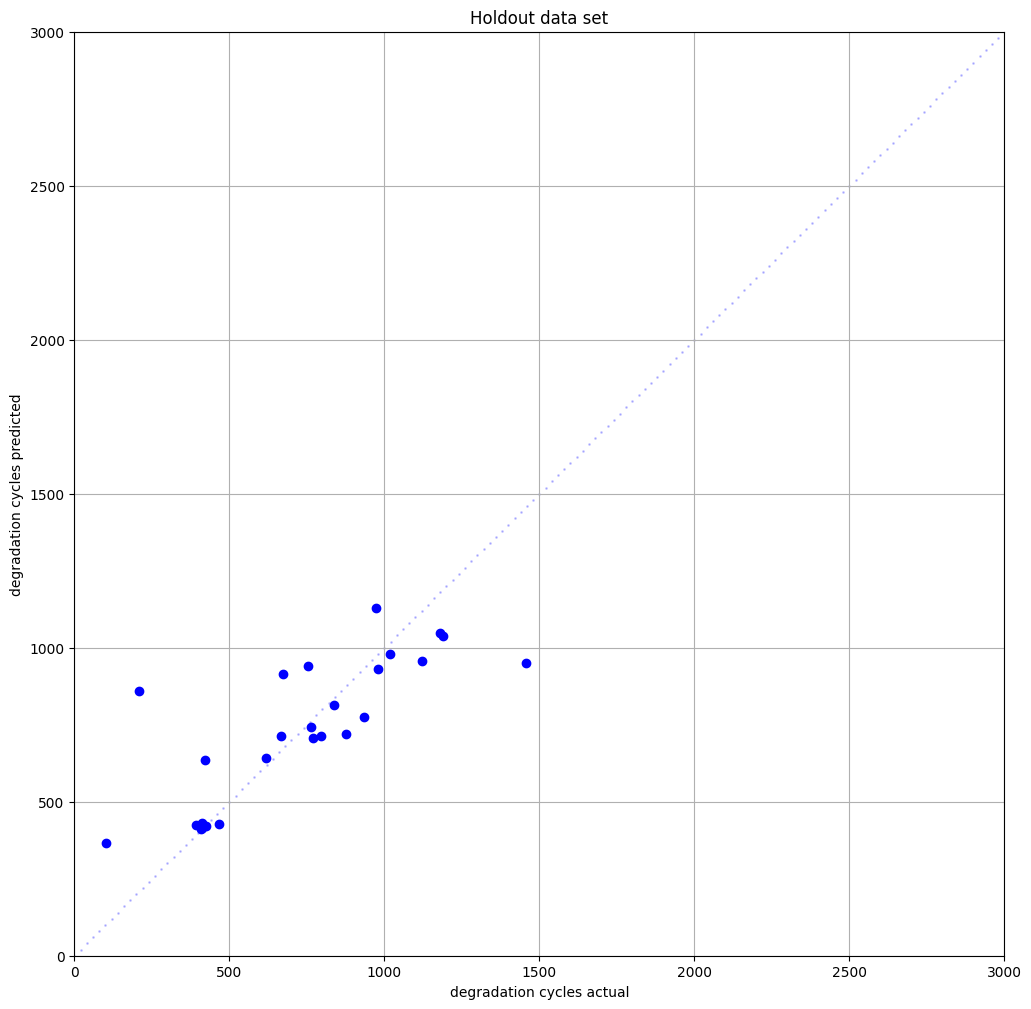

In [10]:
rfm = Tree_Model(Model = RandomForestRegressor,
                 params = rfm_params,
                 cycle_max=3000
                 )

rfm.fit(X_train, y_train)
y_test_pred = rfm.predict(X_test, y_test)

### Feature importance summary

# From above, the HOLDOUT MdAPE = 8.03, R^2 = 0.705